## Global configuration

In [2]:
dataset_root = "../datasets"

import sys
sys.path.append('../src/')  # analytics package

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Dataset loading and preparation

In [3]:
import pyarrow.compute as pc
from tls_profiling.preprocessing import build_and_fit_preprocessor, extract_features
from tls_profiling.io import open_tls_parquet_dataset

dataset = open_tls_parquet_dataset(f"{dataset_root}/malware.parquet")

filt = (
    pc.starts_with(pc.field("meta.sample.id"), "25090")    # use meta.sample.id to get only a single day 2025-09-01
)

print(f"Loading dataset...filter={filt}")
df = dataset.to_table(
    filter=filt
).to_pandas()

df.head(10)

Loading dataset...filter=starts_with(meta.sample.id, {pattern="25090", ignore_case=false})


,bs,ps,br,pr,dp,sp,da,sa,ts,td,...,tls.ja4,tls.ja3s,tls.ja4s,meta.sample.id,meta.malware.family,meta.system.os,meta.system.service,meta.application.name,meta.application.process,tls.rec
0,1262,13,8316,12,443,49792,20.72.205.209,10.127.0.189,1.756762e+09,0.941528,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_telemetry,NaN,NaN,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -2..."
1,49974,64,39987,54,443,49801,40.126.31.67,10.127.0.189,1.756762e+09,128.561234,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,NaN,NaN,NaN,"[-226, 3954, -102, -1, -40, 1, 40, -445, -3616..."
2,35832,48,31235,40,443,49803,40.126.31.67,10.127.0.189,1.756762e+09,138.264477,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,NaN,NaN,NaN,"[-226, 3954, -102, -1, -40, 1, 40, -469, -7637..."
3,4529,14,8280,14,443,49804,20.72.205.209,10.127.0.189,1.756762e+09,1.195099,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_telemetry,NaN,NaN,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
4,4035,14,4910,13,443,49806,52.167.17.97,10.127.0.189,1.756762e+09,0.749950,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_telemetry,NaN,NaN,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
5,1982,13,4870,12,443,49807,52.167.17.97,10.127.0.189,1.756762e+09,0.683508,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_telemetry,NaN,NaN,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -9..."
6,2437,19,21862,25,443,49808,52.167.17.97,10.127.0.189,1.756762e+09,0.657093,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_telemetry,NaN,NaN,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
7,1775,25,28988,27,443,49860,74.178.76.128,10.127.0.189,1.756762e+09,0.216118,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_core,NaN,NaN,"[-206, 2488, -102, -1, -40, 1, 40, -82, -264, ..."
8,1134,13,3326,10,443,49861,13.95.31.18,10.127.0.189,1.756762e+09,0.235395,...,t12d1909h2_d83cc789557e_7af1ed941c26,87b9bed0515be16c82bdc44d88a4a0ec,t1204h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_delivery,NaN,NaN,"[-211, 2550, -102, -1, -40, 1, 40, 64, -82, -9..."
9,996,10,3239,8,443,49862,74.178.76.128,10.127.0.189,1.756762e+09,0.173583,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,NaN,windows10-2004-x64,microsoft_core,NaN,NaN,"[-206, 2487, -102, -1, -40, 1, 40, -82, -85, 5..."


## Traing a collection of AEs


In [11]:
MIN_SAMPLES = 100 
MAX_SAMPLES = 1_000
MAX_FAMILIES = 10
VAL_RATIO = 0.2
TEST_RATIO = 0.2
ENCODING_DIM=10
TRAINING_EPOCHS=20

from tls_profiling.autoencoder import run_autoencoder_experiment

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tls_profiling.preprocessing.malware_families import get_families, per_family_split

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print(f" Getting family splits...")

families = get_families(df)
splits = per_family_split(df, families, test_size=TEST_RATIO)

models = {}   # <-- store trained models here

for family, (pre_train_df, test_df) in splits.items():
    pre_train_df = pre_train_df.sort_values("ts", kind="mergesort")
    split_idx = int((1 - VAL_RATIO) * len(pre_train_df))
    split_idx = min(max(split_idx, 1), len(pre_train_df) - 1)
    train_df = pre_train_df.iloc[:split_idx]
    val_df = pre_train_df.iloc[split_idx:]

    print(f"\nFamily: {family}")
    print(f"  ⎯Train size: {len(train_df)}")
    print(f"  ⎯Val size:   {len(val_df)}")
    print(f"  ⎯Test size:  {len(test_df)}")

    if len(train_df) > MIN_SAMPLES:
        print("  Training autoencoder...")
        if len(train_df) > MAX_SAMPLES:
            train_df = train_df.sample(MAX_SAMPLES, random_state=1234)

        # the pipeline must be trained for each sfamily independently:
        pipeline = build_and_fit_preprocessor(extract_features(train_df))

        X_train = pipeline.transform(extract_features(train_df))
        X_val   = pipeline.transform(extract_features(val_df))
        X_test  = pipeline.transform(extract_features(test_df))

        train_result = run_autoencoder_experiment(
            X_train,
            X_val,
            X_test,
            encoding_dim=ENCODING_DIM,
            max_epochs=TRAINING_EPOCHS,
        )
        # Store trained model under family key
        models[family] = train_result
        print(f"  Model stored under key: '{family}'")

    else:
        print("  Not enough samples, skipping.")

    if len(models)>MAX_FAMILIES: break



models

 Getting family splits...

Family: ades_stealer
  ⎯Train size: 884
  ⎯Val size:   222
  ⎯Test size:  277
  Training autoencoder...
train shape=(1768, 157)
val shape=(444, 157)
test shape=(554, 157)
Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2742 - val_loss: 0.0516
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0582 - val_loss: 0.0476
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0515 - val_loss: 0.0413
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0471 - val_loss: 0.0382
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0427 - val_loss: 0.0368
  Model stored under key: 'ades_stealer'

Family: agenttesla
  ⎯Train size: 184
  ⎯Val size:   46
  ⎯Test size:  58
  Training autoencoder...
train shape=(367, 157)
val shape=(92, 157)
test shape=(116, 157)
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.6406 - val_loss: 0.5073
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3065 - val_loss: 0.1030
Epo

{'ades_stealer': AETrainResult(models=AEModels(autoencoder=<Functional name=autoencoder, built=True>, encoder=<Functional name=encoder, built=True>, decoder=<Functional name=decoder, built=True>), stats=AETrainStats(avg_error=0.0010820575602861033, std_error=0.0031674407597783714, min_error=2.907977655981228e-05, max_error=0.01677581325610382, reconstruction_errors=array([3.06980278e-05, 3.06980278e-05, 3.06980278e-05, 3.06980278e-05,
        3.36342228e-05, 3.36342228e-05, 3.36342228e-05, 3.36342228e-05,
        3.36342228e-05, 3.36342228e-05, 3.36342228e-05, 2.90797766e-05,
        2.90797766e-05, 2.90797766e-05, 2.90797766e-05, 2.90797766e-05,
        2.90797766e-05, 2.90797766e-05, 3.23831027e-05, 3.23831027e-05,
        3.23831027e-05, 3.23831027e-05, 3.23831027e-05, 3.23831027e-05,
        3.23831027e-05, 9.89535038e-05, 9.89535038e-05, 9.89535038e-05,
        9.89535038e-05, 9.89535038e-05, 9.89532762e-05, 9.89532762e-05,
        9.89285716e-05, 9.89285716e-05, 9.89285716e-05, 9

## Evaluation of AEs using the input dataset

In [8]:
# ---------------------------------------------------------------------
# Helper: compute AE reconstruction error
# ---------------------------------------------------------------------
def compute_recon_error(model, X):
    """Compute reconstruction error for autoencoder model."""
    recon = model.predict(X)
    return np.mean((X - recon) ** 2, axis=1)


# ---------------------------------------------------------------------
# EVALUATION: model (trained on fam A) → tested on fam B
# ---------------------------------------------------------------------
results = []   # rows for DataFrame

print("\n\n=== Evaluating models across all families ===")

# prepare list of families we will evaluate on
families = list(splits.keys())

for model_family, model in models.items():

    if model is None:
        print(f"Skipping evaluation for '{model_family}' (no trained model).")
        continue

    print(f"\nEvaluating model trained on: {model_family}")
    print(model)

    # Baseline: reconstruction error on its own family
    train_df, test_df = splits[model_family]
    X_self = pipeline.transform(extract_features(test_df))
    err_self = compute_recon_error(model.models.autoencoder, X_self)

    self_mean = np.mean(err_self)
    self_std  = np.std(err_self) + 1e-9

    # Evaluate on all other families
    for target_family in families:
        _, target_test = splits[target_family]
        X_target = pipeline.transform(extract_features(target_test))

        err = compute_recon_error(model.models.autoencoder, X_target)

        row = {
            "model_family": model_family,
            "target_family": target_family,
            "mean": float(np.mean(err)),
            "std": float(np.std(err)),
            "median": float(np.median(err)),
            "p90": float(np.percentile(err, 90)),
            "p95": float(np.percentile(err, 95)),
            "p99": float(np.percentile(err, 99)),
            "delta_mean": float(np.mean(err) - self_mean),
            "z_mean": float((np.mean(err) - self_mean) / self_std),
        }

        results.append(row)

# Convert to DataFrame
df_eval = pd.DataFrame(results)
print("\nEvaluation results:\n", df_eval.head())      



=== Evaluating models across all families ===

Evaluating model trained on: ades_stealer
AETrainResult(models=AEModels(autoencoder=<Functional name=autoencoder, built=True>, encoder=<Functional name=encoder, built=True>, decoder=<Functional name=decoder, built=True>), stats=AETrainStats(avg_error=0.0015228031363188977, std_error=0.004858053586839488, min_error=1.7780715817100553e-05, max_error=0.025702851311806635, reconstruction_errors=array([1.79433249e-05, 1.79433249e-05, 1.79433249e-05, 1.79433249e-05,
       1.89594659e-05, 1.89594659e-05, 1.89594659e-05, 1.89594659e-05,
       1.89594659e-05, 1.89594659e-05, 1.89594659e-05, 1.77962985e-05,
       1.77962985e-05, 1.77962985e-05, 1.77962985e-05, 1.77962985e-05,
       1.77962985e-05, 1.77962985e-05, 1.87327592e-05, 1.87327592e-05,
       1.87327592e-05, 1.87327592e-05, 1.87327592e-05, 1.87327592e-05,
       1.87327592e-05, 5.45877084e-05, 5.45877084e-05, 5.45877084e-05,
       5.45877084e-05, 5.45877084e-05, 5.45876143e-05, 5.458

##  Heatmap Visualization


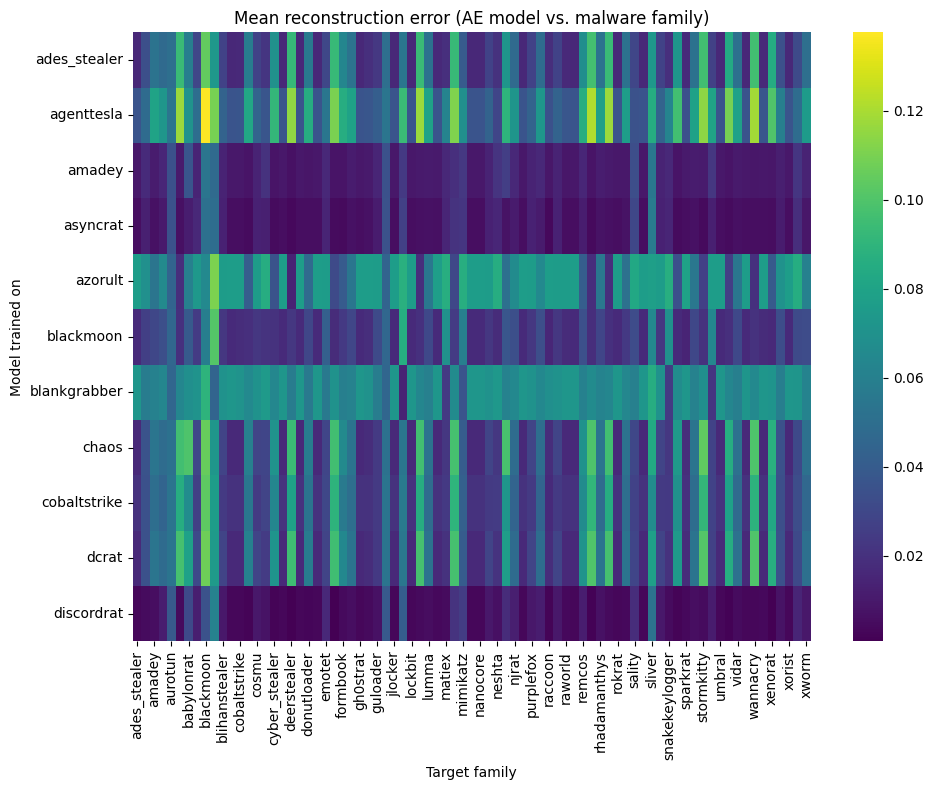

In [9]:
pivot_mean = df_eval.pivot(index="model_family", columns="target_family", values="mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mean, annot=False, cmap="viridis")
plt.title("Mean reconstruction error (AE model vs. malware family)")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()

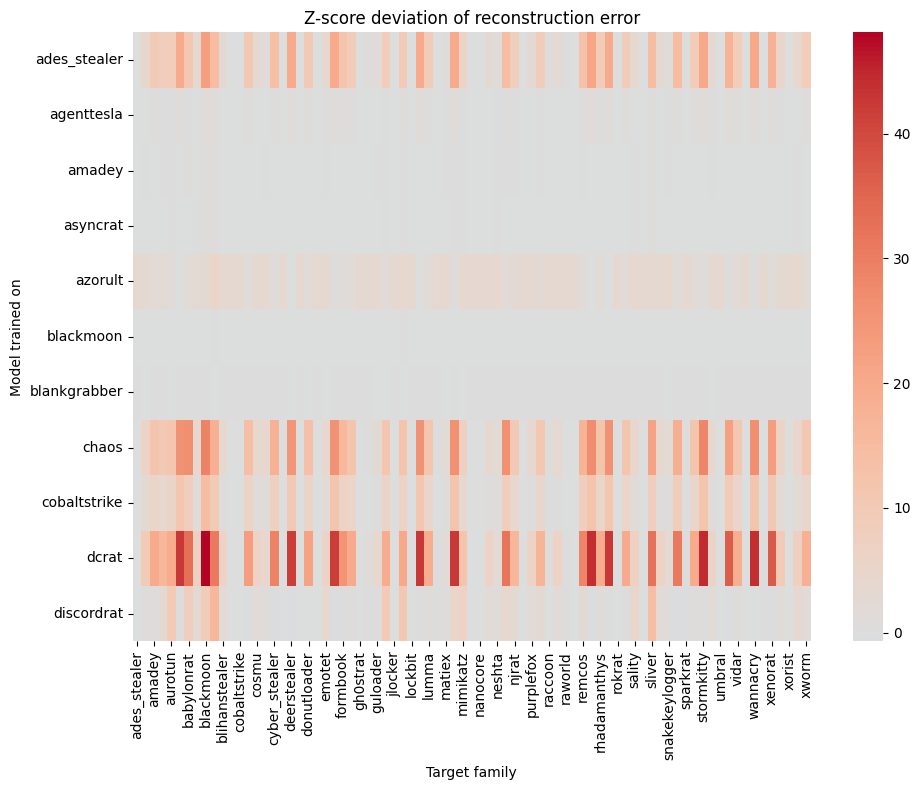

In [10]:
pivot_z = df_eval.pivot(index="model_family", columns="target_family", values="z_mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_z, annot=False, cmap="coolwarm", center=0)
plt.title("Z-score deviation of reconstruction error")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()